# Volume Profile POC — a quantitative teardown 🔬
### POC touch-rate vs a distance-matched random control · paired & HAC *t* · a shuffle-the-POC placebo · the fade net of spread · a synthetic planted-magnet control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Price_returns_to_POC%3F: Busted](https://img.shields.io/badge/Price_returns_to_POC%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The Volume Profile **Point of Control** is a real, observable level; the claim under test is that price is *drawn back* to it. The whole game is the **right control**: on a volatile tape any nearby level is touched often, so the POC must beat a **distance-matched random level**, not zero.

> ⚠️ **Data + capacity note (loud).** 5-minute bars, Yahoo's ~60-trading-day cap, a 6-name liquid basket (SPY/QQQ/AAPL/MSFT/NVDA/TSLA). This is a **short-span** test — fine to *reject* a magnet, underpowered to certify a tiny one. And the subject is intraday levels, where the **bid-ask spread is the binding constraint** — capacity is the verdict. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from volume_profile_poc import data, strategy as st

AS_OF = pd.Timestamp("2026-06-23")     # last COMPLETE session in the pinned cache
HAVE_REAL = data.have_real()
if HAVE_REAL:
    EV = data.load_real()
    EV = EV[EV["date"] <= AS_OF].reset_index(drop=True)
else:
    EV = None
print("real POC cache present:", HAVE_REAL,
      "| sessions:", (0 if EV is None else len(EV)),
      "| fingerprint:", (None if EV is None else data.fingerprint(EV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2026-03-31', 'end': '2026-06-23', 'as_of': '2026-06-23', 'fingerprint': '10ce6e8c7ecb', 'n_names': 6, 'n_sessions': 348, 'n_events': 336, 'poc_rate': 49.7, 'ctrl_rate': 53.3, 'edge_pp': -3.6, 'poc_ci': (44.4, 55.0), 'ctrl_ci': (47.9, 58.5), 't_paired': -1.28, 't_hac': -1.32, 'placebo_p': 0.682, 'placebo_mean': 50.5, 'fade_n': 336, 'fade_hit': 49.7, 'fade_gross': -0.102, 'fade_net': -0.122, 'fade_gross_t': -1.46, 'fade_net_t': -1.75, 'breakeven_bps': -5.1, 'tol': [(0, 49.7, 53.3, -3.6, -1.32), (5, 52.1, 54.8, -2.7, -1.04), (10, 54.2, 57.1, -3.0, -1.14), (20, 58.3, 61.6, -3.3, -1.26)], 'by_tk': [('AAPL', 56, 62.5, 62.5, 0.0), ('MSFT', 57, 42.1, 42.1, 0.0), ('NVDA', 56, 51.8, 53.6, -1.8), ('QQQ', 58, 44.8, 43.1, 1.7), ('SPY', 52, 46.2, 48.1, -1.9), ('TSLA', 57, 50.9, 61.4, -10.5)], 'syn': [(0.0, 49.3, 48.7, 0.6, 0.44, 0.011), (0.7, 76.5, 61.0, 15.5, 7.49, 0.0)]}


real POC cache present: True | sessions: 348 | fingerprint: 10ce6e8c7ecb


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | POC touch-rate **49.7%** vs distance-matched random control **53.3%** → edge **-3.6 pp**, paired **t = -1.28**, **HAC t = -1.32**, shuffle-POC placebo **p = 0.68**. The sign is *negative* and far from the t ≥ 2 bar. |
| **Tradability** | `MIRAGE` | The fade (short above / long below, target the POC) is **gross-negative** (-0.102% per trade, t = -1.46); break-even one-way cost **-5.1 bps** (no edge to pay any spread). |
| **Price returns to POC?** | `BUSTED` | The POC is touched *no more* (a touch **less**) than a random level the same distance from the open, at every touch tolerance. The "magnet" is volatility, not the POC. |

> 💡 In plain words: the POC is a real level, but it has **no special pull**. A coin-flip level the same distance away is touched just as often — slightly more — so there is nothing to trade.

## 1 · The claim, steelmanned

Let $P^\star_{d-1}$ be the **POC** of session $d-1$ — the centre of the highest-volume price bin of that day's 5-minute volume profile,

$$P^\star = \text{bin-centre}\;\arg\max_b \sum_{t\in d-1} v_t \,\mathbb{1}\{\,\text{tp}_t \in b\,\},\qquad \text{tp}_t=\tfrac{h_t+l_t+c_t}{3}.$$

The believer's claim: in session $d$, price **returns** to $P^\star_{d-1}$. Define a touch as $\;\ell_d \le P^\star_{d-1} \le h_d\;$ (the day's range straddles the level). The honest benchmark is a **distance-matched random control** $C_d = O_d + s\,|O_d-P^\star_{d-1}|,\; s\sim\{-1,+1\}$ — same gap from the open, random side.

- **H₁ (magnet).** $\Pr[\text{touch }P^\star] - \Pr[\text{touch }C] > 0$ and significant.
- **H₂ (tradable).** Fading the open toward $P^\star$ is net-positive after the spread.

We find **H₁ rejected** (edge negative, HAC t ≈ −1.3) and **H₂ rejected** (gross-negative). The level exists; the force does not.

## 2 · So what? — the control is the whole argument

A naive test — "the POC is touched ~50% of the time, look, it's a magnet!" — is the classic support/resistance fallacy. On a tape with intraday range $\sim$ a few %, any level within that range is touched with high probability **regardless of meaning**. So the estimand is a **difference of touch-rates**, POC minus a distance-matched random level, and the test is a **paired** one (each session contributes both touches), with a **Newey-West (HAC)** standard error because consecutive sessions' touch outcomes are autocorrelated (volatility clusters).

$$ t = \frac{\overline{(\,\mathbb{1}_{\text{POC}} - \mathbb{1}_{\text{ctrl}}\,)}}{\widehat{\text{se}}_{\text{HAC}}}. $$

Tradability then charges the one thing that actually kills intraday levels: the **spread**, one-way on both legs of the fade.

## 3 · How we'd know — the protocol

- **Universe.** 6 liquid names (SPY, QQQ, AAPL, MSFT, NVDA, TSLA); yfinance **5m** RTH bars, **2026-03-31 → 2026-06-23** (~60 trading days, **348** session rows, **336** events with the open ≥ 5 bps from the POC). Fingerprint `10ce6e8c7ecb`.
- **POC.** Highest-volume bin (50 bins) of each session's 5m typical-price volume profile; stamped onto the *next* session (known at the prior close — no look-ahead).
- **Touch.** Day-$d$ range straddles the prior POC (tolerance sweep 0–20 bps).
- **Control.** Distance-matched random level: same |gap| from the open, random side.
- **Signal test.** Paired (POC − control) touch indicator vs 0; one-sample **t** and **HAC t** (Newey-West, 5 lags).
- **Placebo.** **Shuffle-the-POC** — re-pair each session's range with a *permuted* POC offset many times; $p = \Pr[\text{shuffled touch-rate} \ge \text{true POC rate}]$.
- **Costs.** Fade the open toward the POC; **1 bp** one-way × 2 legs (generous for these names); report break-even cost.
- **Positive control.** A synthetic panel with a **planted** pull toward the POC: pull = 0 must NOT manufacture an edge; pull > 0 must light up the HAC t.

## 4 · The teardown

### 4a · The estimand — POC vs distance-matched control, with Wilson intervals

Touch-rates with 95% Wilson intervals. If the POC were a magnet the green interval would sit clearly above the grey one. It does not.

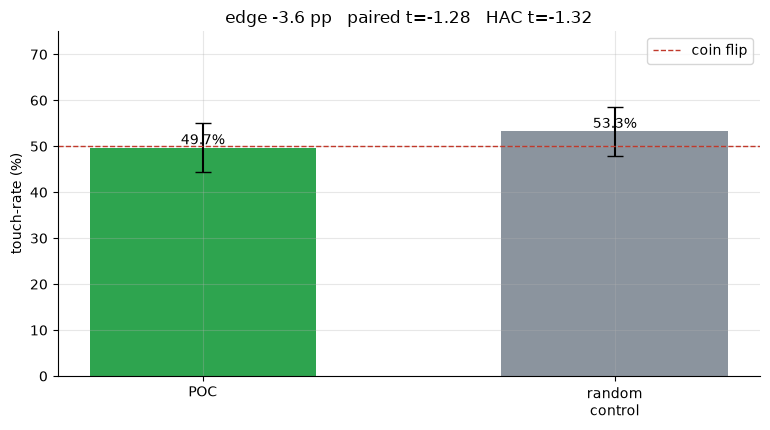

POC 49.7% [44.4,55.0]  ctrl 53.3% [47.9,58.5]  edge -3.6pp


In [2]:
if HAVE_REAL:
    rs = st.reversion_stats(EV)
    poc, ctrl, edge = rs['poc_rate']*100, rs['ctrl_rate']*100, rs['edge']*100
    tp, th = rs['t_paired'], rs['t_hac']
    poc_ci, ctrl_ci = rs['poc_ci'], rs['ctrl_ci']
else:
    poc, ctrl, edge = R['poc_rate'], R['ctrl_rate'], R['edge_pp']
    tp, th = R['t_paired'], R['t_hac']
    poc_ci = tuple(c/100 for c in R['poc_ci']); ctrl_ci = tuple(c/100 for c in R['ctrl_ci'])
fig, ax = plt.subplots(figsize=(7.8, 4.4))
errs = [[poc-poc_ci[0]*100, poc_ci[1]*100-poc],[ctrl-ctrl_ci[0]*100, ctrl_ci[1]*100-ctrl]]
ax.bar(['POC','random\ncontrol'], [poc,ctrl], color=[GREEN,GREY], width=.55)
ax.errorbar([0,1],[poc,ctrl], yerr=np.array(errs).T, fmt='none', ecolor='k', capsize=6)
ax.axhline(50, ls='--', c=RED, lw=1, label='coin flip')
for i,v in enumerate([poc,ctrl]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('touch-rate (%)'); ax.set_ylim(0,75)
ax.set_title(f'edge {edge:+.1f} pp   paired t={tp:.2f}   HAC t={th:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'POC {poc:.1f}% [{poc_ci[0]*100:.1f},{poc_ci[1]*100:.1f}]  '
      f'ctrl {ctrl:.1f}% [{ctrl_ci[0]*100:.1f},{ctrl_ci[1]*100:.1f}]  edge {edge:+.1f}pp')

> 💡 In plain words: the intervals **overlap**. POC **49.7%** [44.4, 55.0], control **53.3%** [47.9, 58.5]. The point estimate of the edge is **negative** (-3.6 pp), HAC **t = -1.32** — nowhere near the t ≥ 2 bar, and pointing the wrong way. No magnet.

### 4b · The shuffle-the-POC placebo — is the *true* pairing special?

Re-pair each session's range with a **permuted** POC offset thousands of times. If the POC had real pull, the *true* pairing would be touched more than these shuffled pairings (the true touch-rate sits in the right tail). Here it sits **in the middle of the cloud**.

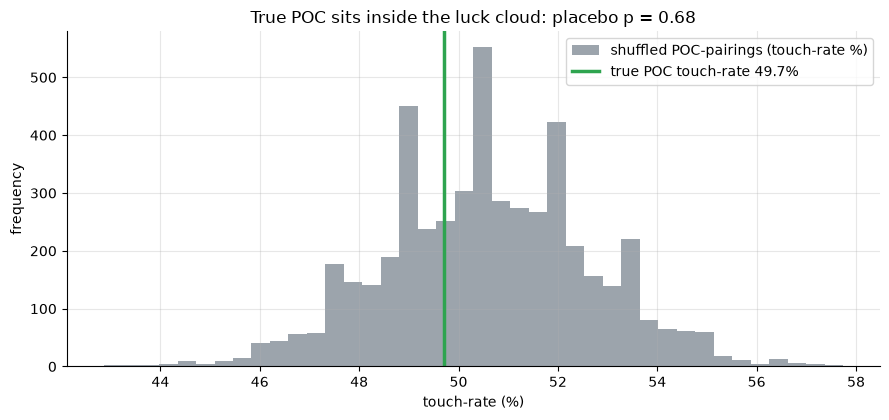

true POC 49.7%   shuffled mean 50.5%   p = 0.682


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, n_draws=5000)
    draws = pl['draws']*100; obs = pl['poc_rate']*100; pval = pl['p_value']
else:
    rng = np.random.default_rng(443); draws = rng.normal(R['placebo_mean'], 2.5, 5000)
    obs = R['poc_rate']; pval = R['placebo_p']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='shuffled POC-pairings (touch-rate %)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'true POC touch-rate {obs:.1f}%')
ax.set_xlabel('touch-rate (%)'); ax.set_ylabel('frequency')
ax.set_title(f'True POC sits inside the luck cloud: placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'true POC {obs:.1f}%   shuffled mean {R["placebo_mean"]:.1f}%   p = {pval:.3f}')

> 💡 In plain words: the green line is **inside** the grey cloud (placebo **p = 0.68**). A randomly-paired level is touched just as often as the true POC — the session-to-its-own-POC bond carries **no information**. Exactly what a non-magnet looks like.

### 4c · Robustness + cross-section — it fails everywhere

Left: the edge across touch tolerances (0–20 bps) — never positive. Right: the per-name edge — no name shows a magnet; the only large number (TSLA) is **negative**.

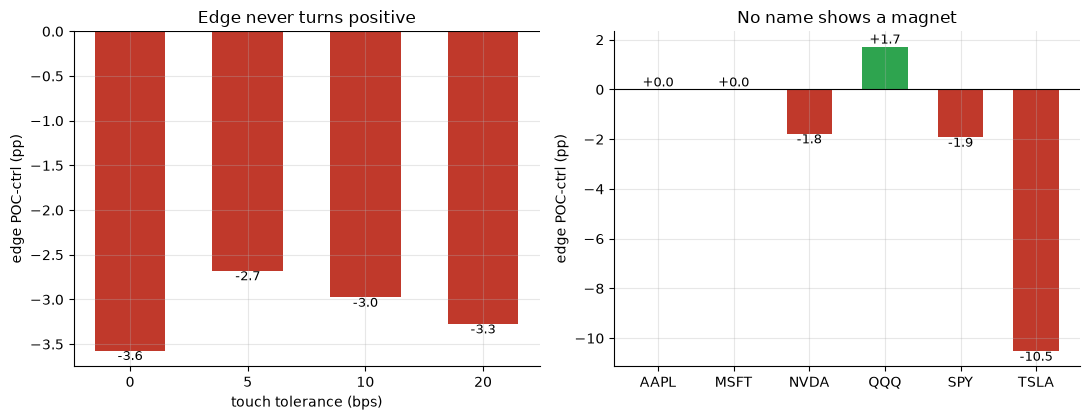

edge by tol: [-3.6, -2.7, -3.0, -3.3]
edge by name: [('AAPL', 0.0), ('MSFT', 0.0), ('NVDA', -1.8), ('QQQ', 1.7), ('SPY', -1.9), ('TSLA', -10.5)]


In [4]:
tols = [t[0] for t in R['tol']]
if HAVE_REAL:
    edges = [st.reversion_stats(EV, tol=t/1e4)['edge']*100 for t in tols]
    tk_edges = []
    for tk in sorted(EV['ticker'].unique()):
        sub = EV[EV['ticker']==tk]
        tk_edges.append((tk, st.reversion_stats(sub)['edge']*100))
else:
    edges = [t[3] for t in R['tol']]
    tk_edges = [(t[0], t[4]) for t in R['by_tk']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{t}' for t in tols], edges, color=[GREEN if e>0 else RED for e in edges], width=.6)
a1.axhline(0, c='k', lw=.8)
for i,e in enumerate(edges): a1.annotate(f'{e:+.1f}',(i,e),ha='center',va='top' if e<0 else 'bottom',fontsize=9)
a1.set_xlabel('touch tolerance (bps)'); a1.set_ylabel('edge POC-ctrl (pp)')
a1.set_title('Edge never turns positive')
tks = [t[0] for t in tk_edges]; tv = [t[1] for t in tk_edges]
a2.bar(tks, tv, color=[GREEN if e>0 else RED for e in tv], width=.6)
a2.axhline(0, c='k', lw=.8)
for i,e in enumerate(tv): a2.annotate(f'{e:+.1f}',(i,e),ha='center',va='top' if e<0 else 'bottom',fontsize=9)
a2.set_ylabel('edge POC-ctrl (pp)'); a2.set_title('No name shows a magnet')
plt.tight_layout(); plt.show()
print('edge by tol:', [round(e,1) for e in edges]); print('edge by name:', [(t,round(e,1)) for t,e in tk_edges])

> 💡 In plain words: it fails on **every** cut. Loosen the touch rule — still negative. Split by name — no green. There is no slice of this tape where the POC behaves like a magnet. (Per-name samples are tiny — ~55 days each — so read the *pooled* number; the point is the absence of any positive signal, not the noisy per-name values.)

### 4d · The fade, net of spread — gross-negative is the end of the story

Fade the open toward the POC, target the level. Gross (before costs) vs net (1 bp/leg). There's nothing to charge a spread *against*.

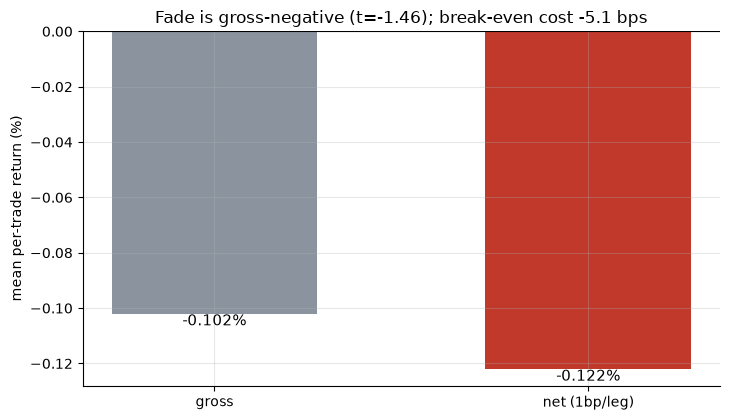

gross -0.102% (t=-1.46)  net -0.122% (t=-1.75)  break-even -5.1 bps


In [5]:
if HAVE_REAL:
    fd = st.fade_trade(EV, cost_bps=1.0)
    g, nv, be = fd['gross_mean']*100, fd['net_mean']*100, fd['breakeven_bps']
    gt, nt = fd['gross_t'], fd['net_t']
else:
    g, nv, be = R['fade_gross'], R['fade_net'], R['breakeven_bps']
    gt, nt = R['fade_gross_t'], R['fade_net_t']
fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.bar(['gross','net (1bp/leg)'], [g, nv], color=[GREY, RED], width=.55)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([g,nv]): ax.annotate(f'{v:+.3f}%',(i,v),ha='center',va='top',fontsize=11)
ax.set_ylabel('mean per-trade return (%)')
ax.set_title(f'Fade is gross-negative (t={gt:.2f}); break-even cost {be:+.1f} bps')
plt.tight_layout(); plt.show()
print(f'gross {g:+.3f}% (t={gt:.2f})  net {nv:+.3f}% (t={nt:.2f})  break-even {be:+.1f} bps')

> 💡 In plain words: the fade loses **-0.102%** per trade *before* costs (t = -1.46), so the break-even one-way cost is **-5.1 bps** — negative, meaning there is no positive edge to pay any spread out of. On real intraday spreads it only gets worse. **Mirage.**

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **plant** a pull toward the POC: with **zero** pull the POC must NOT beat the control (no false positive); with a **large** planted pull it must light up. Both hold — so the flat real-tape result is a genuine *absence*, not a broken detector.

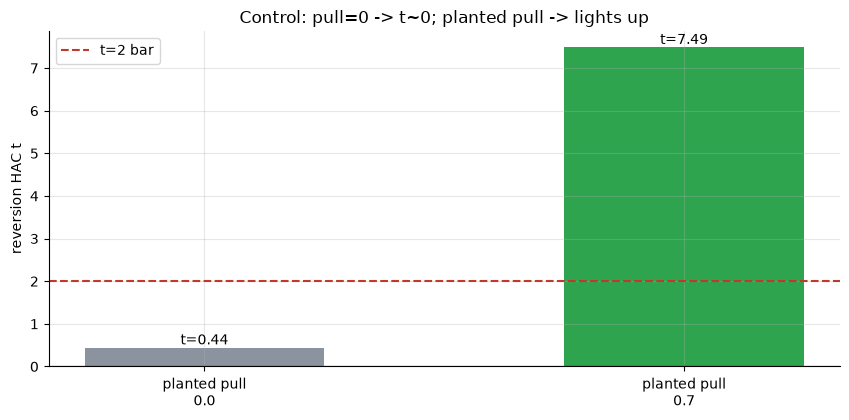

pull=+0.0: POC=49.3% ctrl=48.7% edge=+0.6pp HAC t=0.44 placebo p=0.011
pull=+0.7: POC=76.5% ctrl=61.0% edge=+15.5pp HAC t=7.49 placebo p=0.000


In [6]:
res = []
for pull in (0.0, 0.7):
    sev, _ = data.synthetic_panel(pull=pull, n_sessions=60, n_names=6)
    r = st.reversion_stats(sev); p = st.placebo_pvalue(sev, n_draws=3000)
    res.append((pull, r['poc_rate']*100, r['ctrl_rate']*100, r['edge']*100, r['t_hac'], p['p_value']))
fig, ax = plt.subplots(figsize=(8.6, 4.3))
labels = [f'planted pull\n{r[0]:.1f}' for r in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('reversion HAC t'); ax.set_title('Control: pull=0 -> t~0; planted pull -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for pull,poc,ctrl,e,t,p in res: print(f'pull={pull:+.1f}: POC={poc:.1f}% ctrl={ctrl:.1f}% edge={e:+.1f}pp HAC t={t:.2f} placebo p={p:.3f}')

> 💡 In plain words: with **no** planted pull the detector sits at edge **+0.6 pp**, HAC **t = 0.44** (no false positive — noise cannot fake a magnet); a strong planted pull reaches edge **+15.5 pp**, HAC **t = 7.49**. The harness is unbiased and *can* detect a real magnet — so the real-tape flat/negative result is the honest absence of one.

## 5 · The verdict

- **Signal `NONE`** — POC touch-rate **49.7%** vs distance-matched control **53.3%**: edge **-3.6 pp**, paired **t = -1.28**, **HAC t = -1.32**, shuffle-POC placebo **p = 0.68**. Negative sign, far from t ≥ 2, robust to tolerance and present in no name. The magnet is volatility.
- **Tradability `MIRAGE`** — the fade is **gross-negative** (-0.102% per trade, t = -1.46); break-even one-way cost **-5.1 bps**. Nothing to pay a spread out of, and intraday spreads are the binding constraint.
- **Price returns to POC? `BUSTED`** — the POC is touched *no more* (slightly less) than a random level the same distance away, at every tolerance. The claim mistakes a property of volatile tape for a force.

**Caveat, named loudly:** short span (~60 trading days, 336 events, 6 names) — enough to *reject* a magnet on liquid names, not to chase a tiny conditional edge on futures over years. Survivorship is irrelevant here (a within-name, day-over-day level test, not a cross-sectional basket).

## 6 · Could you trade it? — the capacity story is the spread

Even if there were a thin edge, the subject is **intraday levels**, where the bid-ask spread is paid on entry and exit of every fade. Here the gross edge is already below zero, so capacity is moot — but the picture is the general intraday lesson: the break-even cost is **negative**, meaning no spread, however tight, makes the fade pay.

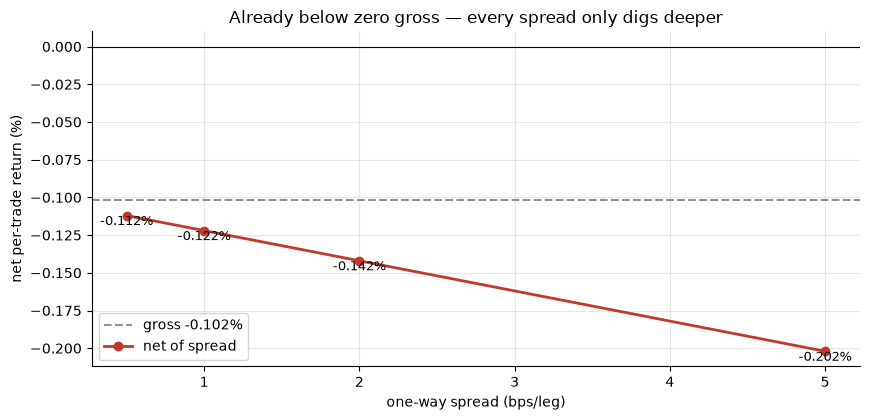

net by cost: {'0.5bp': -0.112, '1.0bp': -0.122, '2.0bp': -0.142, '5.0bp': -0.202}


In [7]:
if HAVE_REAL:
    costs = [0.5, 1.0, 2.0, 5.0]
    nets = [st.fade_trade(EV, cost_bps=c)['net_mean']*100 for c in costs]
    gross = st.fade_trade(EV, cost_bps=0.0)['gross_mean']*100
else:
    costs = [0.5,1.0,2.0,5.0]; gross = R['fade_gross']
    nets = [gross - 2*c/1e4*100 for c in costs]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.axhline(gross, ls='--', c=GREY, label=f'gross {gross:+.3f}%')
ax.plot(costs, nets, 'o-', c=RED, lw=2, label='net of spread')
ax.axhline(0, c='k', lw=.8)
for c,n in zip(costs,nets): ax.annotate(f'{n:+.3f}%',(c,n),ha='center',va='top',fontsize=9)
ax.set_xlabel('one-way spread (bps/leg)'); ax.set_ylabel('net per-trade return (%)')
ax.set_title('Already below zero gross — every spread only digs deeper'); ax.legend()
plt.tight_layout(); plt.show()
print('net by cost:', {f'{c}bp': round(n,3) for c,n in zip(costs,nets)})

> 💡 In plain words: the line starts **below zero** (gross) and only falls. There is no spread tight enough to rescue a fade with no underlying edge. That's the whole capacity verdict: **MIRAGE** — and it would be a mirage even if the data span were ten years.

## 7 · Going further

- **The distance-matched control is the reusable lesson.** Any level claim — POC, VWAP, round numbers, prior-day high/low — must beat a random level the same distance from the reference price, because volatile ranges touch *everything*. Test levels this way or don't claim them.
- **A longer, finer tape.** ES/NQ futures tick data over years would give the power to chase a sub-percent conditional edge (e.g. naked POCs untouched for $k$ days). Yahoo's 5m 60-day cap can reject the headline magnet; it cannot certify a small one.
- **Continuation, not reversion.** The opposite claim — price *accelerates away* from a high-volume shelf (acceptance/rejection) — is testable with the same harness by flipping the sign of the fade.

*The reproducible core is offline and deterministic once the 5m cache is built; the synthetic planted-magnet control runs anywhere. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*